In [ ]:
#total number of stars in Gaia-Tess catalog 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = pd.read_csv("TESS_M=0.4_RP=15.csv")

print("Number of stars:", len(file))
#file.head()

Number of stars: 140813


In [ ]:
# limited sample from catalog, targets with d < 20 pc and magnitude < 16

import pandas as pd
import numpy as np

targets = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

print(targets.head())
print(targets.columns)
print("Total rows:", len(targets))
print("Unique stars:", targets["ID"].nunique())

                  ID DataType  Sector  Exposure_Time  FFI_Avail  SPOC_Avail
0    769456276704128      FFI     4.0    1425.599419       True        True
1    769456276704128      FFI    31.0     475.199790       True        True
2    769456276704128     SPOC     4.0     120.000000       True        True
3    769456276704128     SPOC    31.0     120.000000       True        True
4  16302463200535040      FFI    31.0     475.199790       True        True
Index(['ID', 'DataType', 'Sector', 'Exposure_Time', 'FFI_Avail', 'SPOC_Avail'], dtype='object')
Total rows: 8955
Unique stars: 736


In [3]:
stars = targets.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail", "max"),
    FFI_Avail=("FFI_Avail", "max"),
    n_rows=("ID", "size")
).reset_index()

In [4]:
print(stars.head())
print("Unique stars:", len(stars))

                  ID  SPOC_Avail  FFI_Avail  n_rows
0    769456276704128        True       True       4
1  16302463200535040        True       True      11
2  18986817760556416        True       True      11
3  35398295820372864       False       True       5
4  57739208163471744        True       True       6
Unique stars: 736


In [ ]:
# count of the limited sample with SPOC and without SPOC

print("Stars with SPOC:", (stars["SPOC_Avail"] == True).sum())
print("Stars without SPOC:", (stars["SPOC_Avail"] == False).sum())

Stars with SPOC: 691
Stars without SPOC: 45


In [6]:
catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

print(catalog.columns)
print(limited.columns)

Index(['solution_id', 'designation', 'source_id', 'random_index', 'ref_epoch',
       'ra', 'ra_error', 'dec', 'dec_error', 'parallax',
       ...
       'azero_gspphot', 'azero_gspphot_lower', 'azero_gspphot_upper',
       'ag_gspphot', 'ag_gspphot_lower', 'ag_gspphot_upper',
       'ebpminrp_gspphot', 'ebpminrp_gspphot_lower', 'ebpminrp_gspphot_upper',
       'libname_gspphot'],
      dtype='object', length=222)
Index(['ID', 'DataType', 'Sector', 'Exposure_Time', 'FFI_Avail', 'SPOC_Avail'], dtype='object')


In [7]:
catalog["source_id"] = catalog["source_id"].astype(str).str.replace(".0","",regex=False)
limited["ID"] = limited["ID"].astype(str).str.replace(".0","",regex=False)

In [8]:
cols = [
    "source_id",
    "phot_g_mean_mag",
    "phot_rp_mean_mag",
    "parallax"
]

merged = limited.merge(
    catalog[cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

In [9]:
print(merged.head())
print("Rows:", len(merged))
print("Missing magnitudes:", merged["phot_g_mean_mag"].isna().sum())

                  ID DataType  Sector  Exposure_Time  FFI_Avail  SPOC_Avail  \
0    769456276704128      FFI     4.0    1425.599419       True        True   
1    769456276704128      FFI    31.0     475.199790       True        True   
2    769456276704128     SPOC     4.0     120.000000       True        True   
3    769456276704128     SPOC    31.0     120.000000       True        True   
4  16302463200535040      FFI    31.0     475.199790       True        True   

           source_id  phot_g_mean_mag  phot_rp_mean_mag   parallax  
0    769456276704128         14.59925         13.258915  53.084368  
1    769456276704128         14.59925         13.258915  53.084368  
2    769456276704128         14.59925         13.258915  53.084368  
3    769456276704128         14.59925         13.258915  53.084368  
4  16302463200535040         11.09795          9.947433  58.468956  
Rows: 8955
Missing magnitudes: 0


In [10]:
merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    FFI_Avail=("FFI_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first")
).reset_index()

In [11]:
print(stars.head())
print("Unique stars:", len(stars))

                    ID  SPOC_Avail  FFI_Avail  phot_g_mean_mag  \
0  1016640817918422272        True       True        11.779119   
1  1017783146073299328        True       True        12.093691   
2  1038195201485531776        True       True        13.494663   
3  1041395708035677312        True       True        13.642239   
4  1056860923195191936        True       True        13.395333   

   phot_rp_mean_mag   parallax  distance_pc     color  
0         10.586284  53.659143    18.636153  1.192835  
1         10.691236  55.733804    17.942432  1.402455  
2         12.185511  64.237361    15.567265  1.309153  
3         12.374018  56.668729    17.646417  1.268221  
4         12.100451  57.020068    17.537685  1.294882  
Unique stars: 736


In [12]:
spoc = stars[stars["SPOC_Avail"] == True]
non_spoc = stars[stars["SPOC_Avail"] == False]

print("Total stars:", len(stars))
print("SPOC stars:", len(spoc))
print("Non-SPOC stars:", len(non_spoc))

Total stars: 736
SPOC stars: 691
Non-SPOC stars: 45


In [14]:
merged = limited.merge(
    catalog[["source_id","phot_g_mean_mag","phot_rp_mean_mag","parallax"]],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

merged.to_csv(
    "limited_sample_with_stellar_properties.csv",
    index=False
)

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first")
).reset_index()


In [15]:
stars.to_csv(
    "unique_stars_with_spoc_properties.csv",
    index=False
)

In [16]:
import pandas as pd

catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

catalog["source_id"] = catalog["source_id"].astype(str)
limited["ID"] = limited["ID"].astype(str)

radius_cols = [
    "source_id",
    "radius",
    "radius+",
    "radius-"
]

merged = limited.merge(
    catalog[radius_cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged.to_csv(
    "limited_sample_with_radius.csv",
    index=False
)



In [17]:
stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    radius=("radius","first"),
    radius_plus=("radius+","first"),
    radius_minus=("radius-","first")
).reset_index()

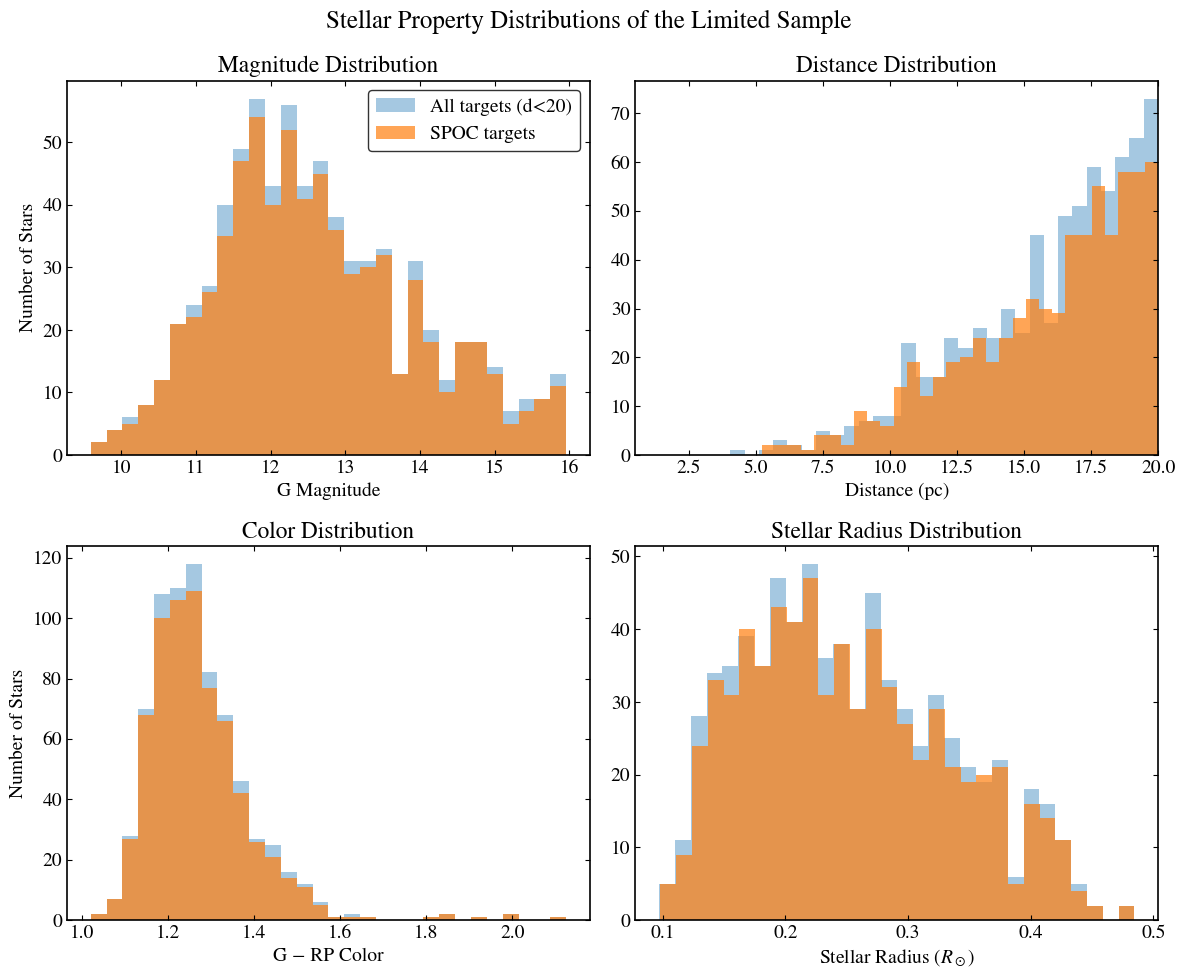

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
    })

catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

catalog["source_id"] = catalog["source_id"].astype(str).str.replace(".0","",regex=False)
limited["ID"] = limited["ID"].astype(str).str.replace(".0","",regex=False)

cols = [
    "source_id",
    "phot_g_mean_mag",
    "phot_rp_mean_mag",
    "parallax",
    "radius",
    "radius+",
    "radius-"
]

merged = limited.merge(
    catalog[cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

merged.to_csv(
    "limited_sample_with_stellar_properties.csv",
    index=False
)

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    FFI_Avail=("FFI_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first"),
    radius=("radius","first"),
    radius_plus=("radius+","first"),
    radius_minus=("radius-","first")
).reset_index()

stars.to_csv(
    "unique_stars_with_spoc_properties.csv",
    index=False
)

spoc = stars[stars["SPOC_Avail"] == True]
non_spoc = stars[stars["SPOC_Avail"] == False]

fig, axs = plt.subplots(2,2, figsize=(12,10))

# magnitude distribution
axs[0,0].hist(stars["phot_g_mean_mag"], bins=30, alpha = 0.4, label="All targets (d<20)")
axs[0,0].hist(spoc["phot_g_mean_mag"], bins=30, alpha = 0.7, label="SPOC targets")
axs[0,0].set_xlabel("G Magnitude")
axs[0,0].set_ylabel("Number of Stars")
axs[0,0].set_title("Magnitude Distribution")
axs[0,0].legend(edgecolor="black")

# distance distribution
axs[0,1].hist(stars["distance_pc"], bins=30, alpha=0.4, label="All stars")
axs[0,1].hist(spoc["distance_pc"], bins=30, alpha=0.7, label="SPOC stars")
axs[0,1].set_xlabel("Distance (pc)")
axs[0,1].set_title("Distance Distribution")
#axs[0,1].legend()
axs[0,1].set_xlim(0.5, 20)


# color distribution, SPOC stars are mostly bluer
axs[1,0].hist(stars["color"], bins=30, alpha=0.4, label="All stars")
axs[1,0].hist(spoc["color"], bins=30, alpha=0.7, label="SPOC stars")
axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("Number of Stars")
axs[1,0].set_title("Color Distribution")
#axs[1,0].legend()

# radius distribution
# tests transit depth, delta = (R_planet / R_star)^2, so smaller stars have deeper transits for a given planet size, making them easier to detect
axs[1,1].hist(stars["radius"], bins=30, alpha=0.4, label="All stars")
axs[1,1].hist(
    spoc["radius"],
    bins=30,
    alpha=0.7,
    
    label="SPOC stars"
)
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
axs[1,1].set_title("Stellar Radius Distribution")
#axs[1,1].legend()

fig.suptitle("Stellar Property Distributions of the Limited Sample", fontsize=18)

plt.tight_layout()
plt.show()

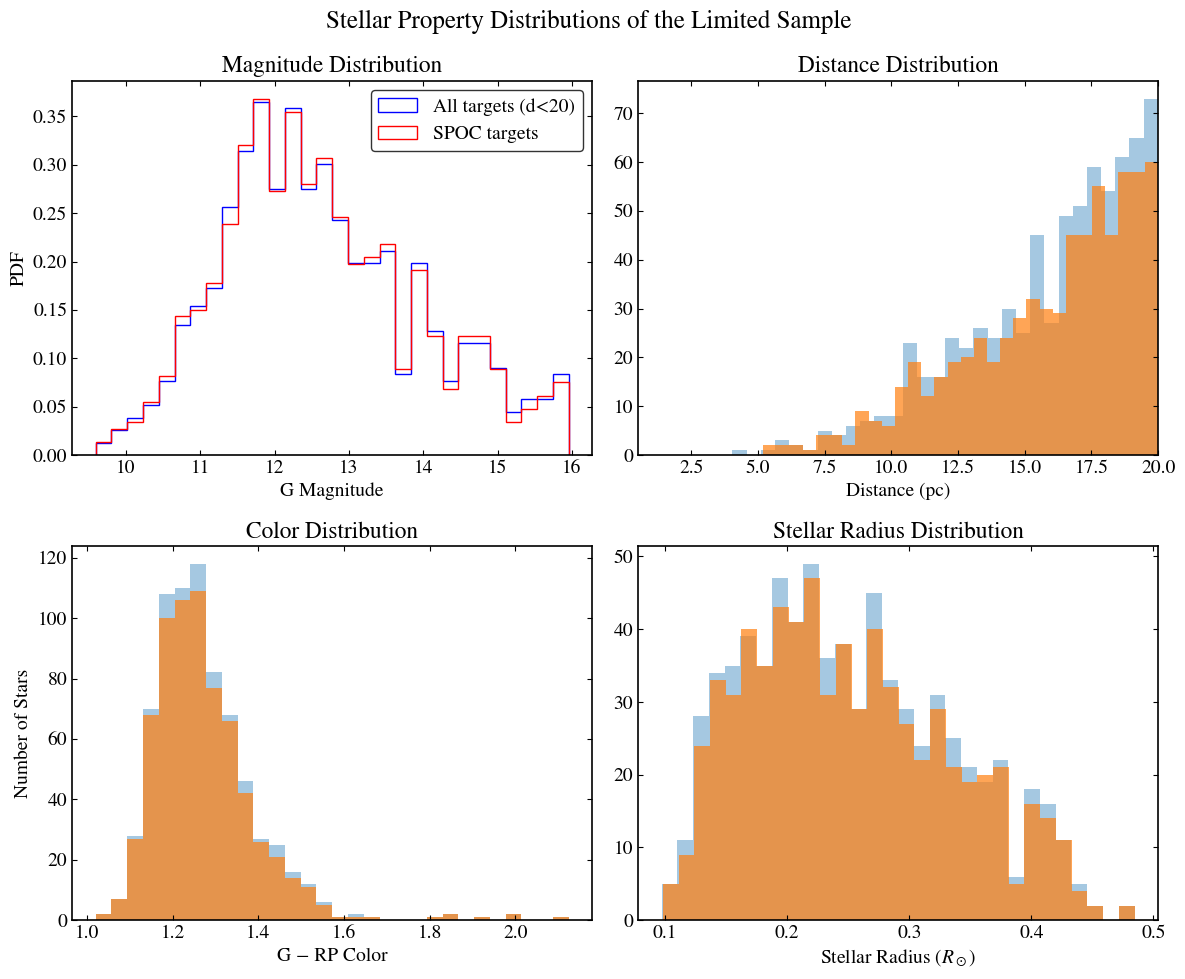

In [20]:
# required only code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

# load the already-saved unique-star file
stars = pd.read_csv("unique_stars_with_spoc_properties.csv")

# make sure SPOC_Avail behaves like a boolean
stars["SPOC_Avail"] = (
    stars["SPOC_Avail"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
    #.fillna(False)
)

# optional cleanup so histograms do not break on bad values
#stars = stars.dropna(subset=["phot_g_mean_mag", "distance_pc", "color", "radius"])
#stars = stars[stars["radius"] > 0]

# SPOC subset
spoc = stars[stars["SPOC_Avail"] == True]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# magnitude distribution
axs[0,0].hist(stars["phot_g_mean_mag"], bins=30,density=True, histtype="step", color='blue', label="All targets (d<20)")
axs[0,0].hist(spoc["phot_g_mean_mag"], bins=30,  density=True, histtype="step", color ='red', label="SPOC targets")
axs[0,0].set_xlabel("G Magnitude")
axs[0,0].set_ylabel("PDF")
axs[0,0].set_title("Magnitude Distribution")
axs[0,0].legend(edgecolor="black")

# distance distribution
axs[0,1].hist(stars["distance_pc"], bins=30, alpha=0.4, label="All stars")
axs[0,1].hist(spoc["distance_pc"], bins=30, alpha=0.7, label="SPOC stars")
axs[0,1].set_xlabel("Distance (pc)")
axs[0,1].set_title("Distance Distribution")
axs[0,1].set_xlim(0.5, 20)

# color distribution
axs[1,0].hist(stars["color"], bins=30, alpha=0.4, label="All stars")
axs[1,0].hist(spoc["color"], bins=30, alpha=0.7, label="SPOC stars")
axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("Number of Stars")
axs[1,0].set_title("Color Distribution")

# radius distribution
axs[1,1].hist(stars["radius"], bins=30, alpha=0.4, label="All stars")
axs[1,1].hist(spoc["radius"], bins=30, alpha=0.7, label="SPOC stars")
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
axs[1,1].set_title("Stellar Radius Distribution")

fig.suptitle("Stellar Property Distributions of the Limited Sample", fontsize=18)

plt.tight_layout()
plt.show()

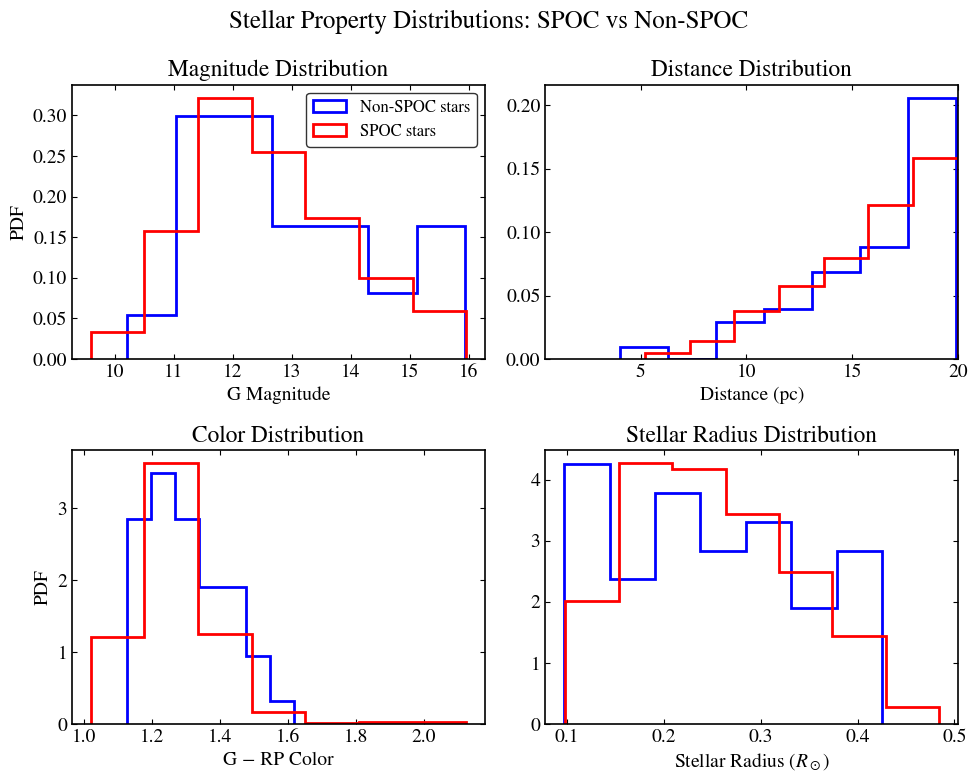

In [ ]:
# plots for spoc and non spoc are very similar
# Which makes sense because your limited sample already selects stars that are ideal for TESS observations.
# The major bias is not happening inside the nearby sample, it occurs when selecting targets from the full stellar catalog.
# SPOC targets: 691, Non-SPOC targets: 45, total: 736

# required only code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

# load the already-saved unique-star file
stars = pd.read_csv("unique_stars_with_spoc_properties.csv")

# make sure SPOC_Avail behaves like a boolean
stars["SPOC_Avail"] = (
    stars["SPOC_Avail"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

# subsets
spoc = stars[stars["SPOC_Avail"] == True]
non_spoc = stars[stars["SPOC_Avail"] == False]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# bin size, non spoc: 45, sqrt(45) ~ 7, spoc: 691, sqrt(691) ~ 26
# N / bins, non spoc: 45/7 ~ 6.4 stars per bin, spoc: 691/26 ~ 26.6 stars per bin
bins = 7
# magnitude distribution
axs[0,0].hist(non_spoc["phot_g_mean_mag"], bins=bins, histtype='step', density=True, color='blue', linewidth=2, label="Non-SPOC stars")
axs[0,0].hist(spoc["phot_g_mean_mag"], bins=bins, histtype='step', density=True, color='red', linewidth=2, label="SPOC stars")
axs[0,0].set_xlabel("G Magnitude")
axs[0,0].set_ylabel("PDF")
axs[0,0].set_title("Magnitude Distribution")
axs[0,0].legend(edgecolor="black", fontsize=12)

# distance distribution
axs[0,1].hist(non_spoc["distance_pc"], bins=bins, density=True, histtype='step', color='blue', linewidth=2, label="Non-SPOC stars")
axs[0,1].hist(spoc["distance_pc"], bins=bins, density=True, histtype='step', color='red', linewidth=2, label="SPOC stars")
axs[0,1].set_xlabel("Distance (pc)")
#axs[0,1].set_ylabel("Probability Density")
axs[0,1].set_title("Distance Distribution")
axs[0,1].set_xlim(0.5, 20)

# color distribution
axs[1,0].hist(non_spoc["color"], bins=bins, density=True, histtype='step', color='blue', linewidth=2, label="Non-SPOC stars")
axs[1,0].hist(spoc["color"], bins=bins, density=True, histtype='step', color='red', linewidth=2, label="SPOC stars")
axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("PDF")
axs[1,0].set_title("Color Distribution")

# radius distribution
axs[1,1].hist(non_spoc["radius"], bins=bins, density=True, histtype='step', color='blue', linewidth=2, label="Non-SPOC stars")
axs[1,1].hist(spoc["radius"], bins=bins, density=True, histtype='step', color='red', linewidth=2, label="SPOC stars")
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
#axs[1,1].set_ylabel("Probability Density")
axs[1,1].set_title("Stellar Radius Distribution")

fig.suptitle("Stellar Property Distributions: SPOC vs Non-SPOC", fontsize=18)

plt.tight_layout()
plt.show()

In [58]:
hist, edges = np.histogram(
    spoc["phot_g_mean_mag"],
    bins=7,
    density=True
)

bin_width = edges[1] - edges[0]

area = np.sum(hist)

print(area)

1.1000869424595587


In [22]:
# count SPOC vs non-SPOC stars

n_spoc = (stars["SPOC_Avail"] == True).sum()
n_non_spoc = (stars["SPOC_Avail"] == False).sum()
n_total = len(stars)

print(f"Total stars in limited sample: {n_total}")
print(f"SPOC stars: {n_spoc}")
print(f"Non-SPOC stars: {n_non_spoc}")

Total stars in limited sample: 736
SPOC stars: 691
Non-SPOC stars: 45


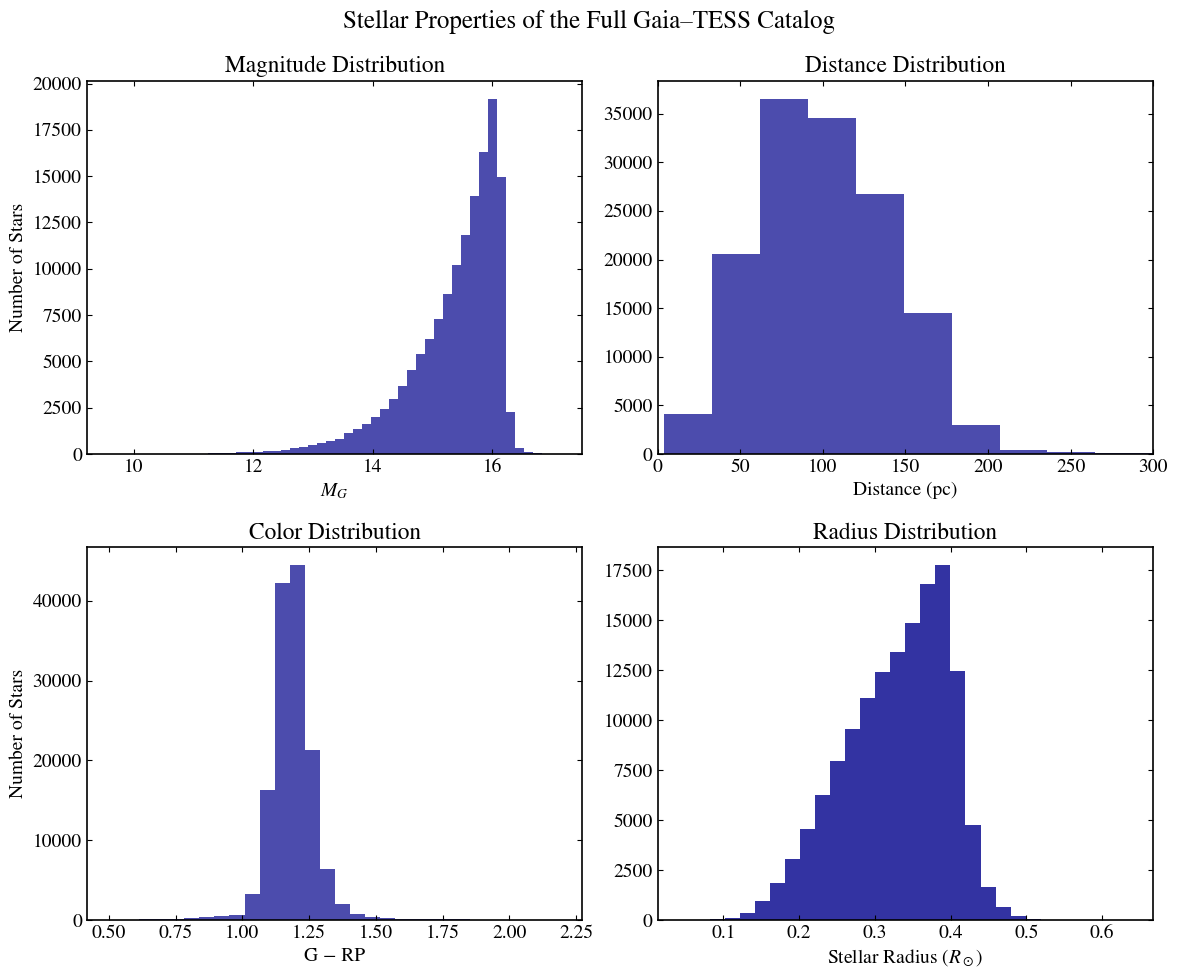

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
    })

catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")

catalog["distance_pc"] = 1000 / catalog["parallax"]

catalog["color"] = (
    catalog["phot_g_mean_mag"] -
    catalog["phot_rp_mean_mag"]
)

catalog = catalog.dropna(subset=["radius"])
catalog = catalog[catalog["radius"] > 0]


fig, axs = plt.subplots(2,2, figsize=(12,10))

# bin size, 140000/30 = 4667, average stars per bin = 4667

# Magnitude distribution
axs[0,0].hist(catalog["phot_g_mean_mag"], bins=50, alpha=0.7, color="darkblue")
axs[0,0].set_xlabel("$M_G$")
axs[0,0].set_ylabel("Number of Stars")
axs[0,0].set_title("Magnitude Distribution")


# Distance distribution
axs[0,1].hist(catalog["distance_pc"], color="darkblue", bins=30, alpha=0.7)
axs[0,1].set_xlabel("Distance (pc)")
axs[0,1].set_title("Distance Distribution")
axs[0,1].set_xlim(0, 300)


# Color distribution
axs[1,0].hist(catalog["color"], bins=30, alpha=0.7, color="darkblue")
axs[1,0].set_xlabel("G − RP")
axs[1,0].set_ylabel("Number of Stars")
axs[1,0].set_title("Color Distribution")


# Radius distribution
axs[1,1].hist(catalog["radius"], bins=30, alpha=0.8, color="darkblue")
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
axs[1,1].set_title("Radius Distribution")

fig.suptitle("Stellar Properties of the Full Gaia–TESS Catalog", fontsize=18)
plt.tight_layout()
plt.show()

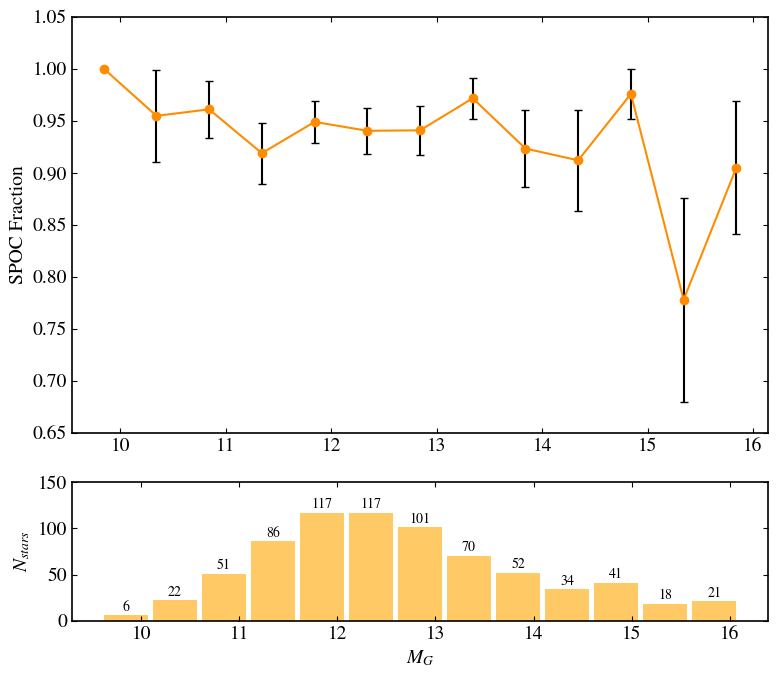

In [ ]:
# should include error bars, fraction values may be noisey in bins with few stars
# add binomial uncertainty, which is sqrt(p*(1-p)/N) where p is the SPOC fraction and N is the total number of stars in the bin
# larger magnitudes have larger error bars due to fewer stars in the magnitude bins
# binomial uncertainty scales as 1/sqrt(N), so bins containing fewer stars will have larger uncertainties and produce larger error bars

# small uncertainty at bright magnitude?
# if all 6 stars were processed by SPOC, then N = 6, p = 6/6 = 1, so uncertainty = sqrt(1*(1-1)/6) = 0, 
# which makes sense since if all stars in the bin are processed by SPOC, then the fraction is exactly 1 with no uncertainty (no visual error bars)
# it does NOT mean the measurement is perfect, just simply from the formula, when the fraction is 0 or 1, the variance is 0.
# This is just a limitation of the binomial approximation, which assumes independent trials and a fixed probability of success. 
# When the observed fraction is 0 or 1, the variance is mathematically zero, but in reality, there may still be uncertainty due to other factors
# not captured by the simple binomial model. 

# SPOC fraction = number of SPOC stars in the bin / total number of stars in the bin
# most bins have a high SPOC fraction,

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
    })

bins = np.arange(stars["phot_g_mean_mag"].min(),
                 stars["phot_g_mean_mag"].max() + 0.5,
                 0.5)

total_counts, edges = np.histogram(stars["phot_g_mean_mag"], bins=bins)

spoc_counts, _ = np.histogram(
    stars.loc[stars["SPOC_Avail"] == True, "phot_g_mean_mag"],
    bins=bins
)

spoc_fraction = np.divide(
    spoc_counts,
    total_counts,
    out=np.zeros_like(spoc_counts, dtype=float),
    where=total_counts > 0
)

# binomial uncertainty
errors = np.sqrt(
    spoc_fraction * (1 - spoc_fraction) / total_counts
)

bin_centers = 0.5 * (edges[:-1] + edges[1:])

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8,7),
    gridspec_kw={"height_ratios": [3,1]}
)

# top panel: SPOC fraction
ax1.errorbar(bin_centers, spoc_fraction, yerr=errors, marker='o', capsize=3, color="darkorange", ecolor="black")

ax1.set_ylabel("SPOC Fraction")
#ax1.set_title("SPOC Fraction vs G Magnitude")
ax1.set_ylim(0.65, 1.05)

# bottom panel: number of stars per bin
ax2.bar(
    bin_centers,
    total_counts,
    width=0.45,
    alpha=0.6,
    color="orange"
)

ax2.set_xlabel("$M_G$")
ax2.set_ylabel("$N_{stars}$")
ax2.set_yticks(np.arange(0, 200, 50))

for x, n in zip(bin_centers, total_counts):
    ax2.text(
        x,
        n+5,          # small vertical offset above the bar
        str(n),
        ha="center",
        fontsize=10
    )


plt.tight_layout()
plt.savefig("spoc_fraction_vs_magnitude.pdf", dpi=300)
plt.show()


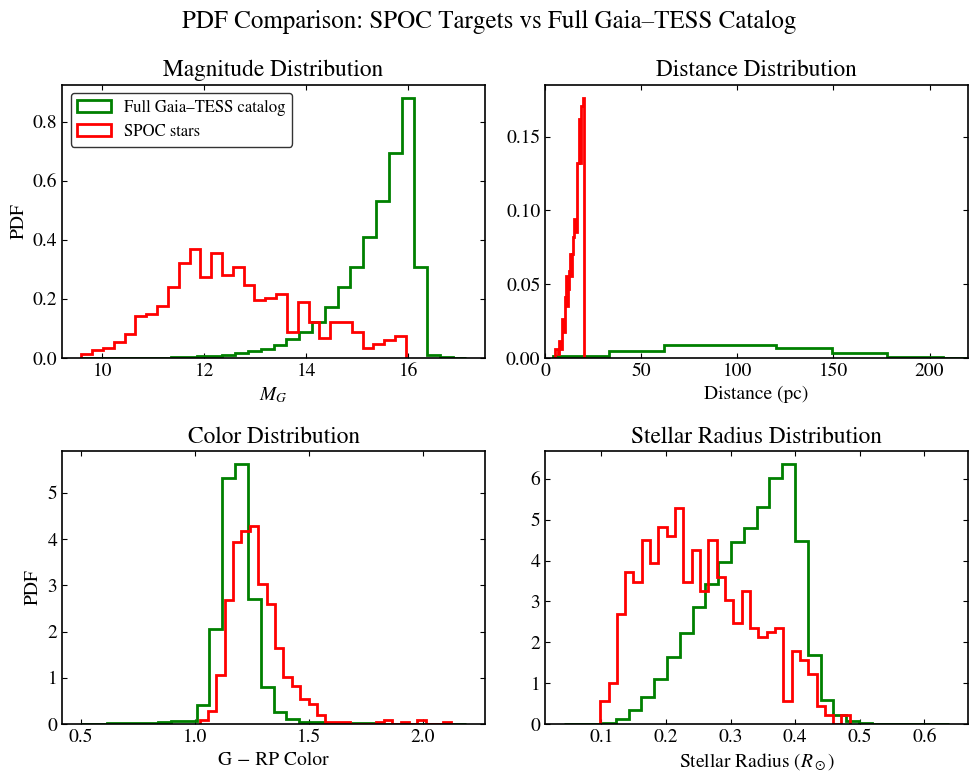

In [ ]:
# plot the PDFs of the full catalog and the SPOC subset for magnitude, distance, color, and radius
# Magnitude: Full catalog has a magnitude peak at 16, SPOC subset peaks at 12
# SPOC targets are biased towards brighter stars compared to the full catalog
# Distance: SPOC targets are biased towards closer stars, with a peak around 20 pc, 
# while the full catalog has a broad distribution from 0 to 200 pc with a median around 100 pc
# SPOC targets are biased towards closer stars compared to the full catalog
# Color: SPOC distribution is shifted towards the right, indicating that SPOC targets are generally redder and cooler than the full catalog
# Radius: SPOC distribution is shifted towards smaller radii, indicating that SPOC targets are generally smaller than the full catalog
# SPOC is biased towards smaller, cooler stars compared to the full catalog

# stars from full catalog: 140813, stars from SPOC subset: 691

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

# load datasets
stars = pd.read_csv("unique_stars_with_spoc_properties.csv")
catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")

# clean SPOC boolean
stars["SPOC_Avail"] = (
    stars["SPOC_Avail"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
)

# compute catalog properties
catalog["distance_pc"] = 1000 / catalog["parallax"]
catalog["color"] = catalog["phot_g_mean_mag"] - catalog["phot_rp_mean_mag"]

catalog = catalog.dropna(subset=["radius"])
catalog = catalog[catalog["radius"] > 0]

# SPOC subset
spoc = stars[stars["SPOC_Avail"] == True]

fig, axs = plt.subplots(2,2, figsize=(10,8))

# sqrt(N) rule for binning, 
bins = 30

# Magnitude PDF
axs[0,0].hist(catalog["phot_g_mean_mag"], bins=bins, density=True, histtype='step', color='green', linewidth=2,label="Full Gaia–TESS catalog")
axs[0,0].hist(spoc["phot_g_mean_mag"], bins=bins, density=True, histtype='step', color='red', linewidth=2, label="SPOC stars")
axs[0,0].set_xlabel("$M_G$")
axs[0,0].set_ylabel("PDF")
axs[0,0].set_title("Magnitude Distribution")
axs[0,0].legend(edgecolor="black", fontsize=12)

# Distance PDF
axs[0,1].hist(catalog["distance_pc"], bins=bins, density=True, histtype='step', linewidth = 2, color='green')
axs[0,1].hist(spoc["distance_pc"], bins=bins, density=True, histtype='step', linewidth = 2, color='red')
axs[0,1].set_xlabel("Distance (pc)")
axs[0,1].set_title("Distance Distribution")
axs[0,1].set_xlim(0,220)

# Color PDF
axs[1,0].hist(catalog["color"], bins=bins, density=True, histtype='step', linewidth = 2, color='green')
axs[1,0].hist(spoc["color"], bins=bins, density=True,histtype='step', linewidth = 2, color='red')

axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("PDF")
axs[1,0].set_title("Color Distribution")

# Radius PDF
axs[1,1].hist(catalog["radius"], bins=bins, density=True, histtype='step', linewidth = 2, color='green')
axs[1,1].hist(spoc["radius"], bins=bins, density=True, histtype='step', linewidth = 2, color='red')
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
axs[1,1].set_title("Stellar Radius Distribution")

fig.suptitle("PDF Comparison: SPOC Targets vs Full Gaia–TESS Catalog", fontsize=18)

plt.tight_layout()
plt.show()